In [29]:
from ensemble import EnsembleVoter
from utils import get_loaders, get_ensemble_predictions, calculate_metrics, get_predictions, plot_confusion_matrix

from pathlib import Path
from baseline_cnn import BaselineCNN
from alexnet import ModifiedAlexNet
import torch
import torchvision.models as models
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print("Using device:", device)

DATA_DIR = Path("../data")

TRAIN_DIR = DATA_DIR / "train"
VALID_DIR = DATA_DIR / "valid"
TEST_DIR = DATA_DIR / "test"

Using device: mps


In [65]:
import importlib
import utils
import ensemble
importlib.reload(utils)
importlib.reload(ensemble)
from utils import get_ensemble_predictions
from ensemble import EnsembleVoter

In [66]:
BATCH_SIZE = 256
train_loader, valid_loader, test_loader = get_loaders(train_dir=TRAIN_DIR, valid_dir=VALID_DIR,
                                                      test_dir=TEST_DIR, image_size=32, batch_size=BATCH_SIZE)

### Loading pretrained models

#### Baseline

In [67]:
checkpoint_path = Path("trained_models")
baseline_checkpoint = torch.load(checkpoint_path/'baseline.pth')
baseline_model = BaselineCNN(input_channels = 3, image_size = 32, conv_channels =[64, 128, 256], kernel_sizes = [3, 3, 3],
                    fc_layers = [128, 64], num_classes = 10)
baseline_model.load_state_dict(baseline_checkpoint["model_state_dict"])

<All keys matched successfully>

#### Alexnet

In [68]:
alexnet_checkpoint = torch.load(checkpoint_path/'alexnet.pth', map_location=device)
alexnet_model = ModifiedAlexNet(num_classes=10)
alexnet_model.load_state_dict(alexnet_checkpoint["model_state_dict"])

<All keys matched successfully>

#### Resnet18

In [69]:
resnet_checkpoint = torch.load(checkpoint_path / 'resnet.pth', map_location=device)
resnet_model = models.resnet18(weights=None)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 10)
resnet_model.load_state_dict(resnet_checkpoint["model_state_dict"])

<All keys matched successfully>

### Ensemble - Hard voting

In [70]:
ensemble = EnsembleVoter(
    models={
        "alexnet": alexnet_model,
        "resnet": resnet_model,
        "baseline": baseline_model
    },
    voting="hard"
)

In [71]:
y_true_hard, y_pred_hard, y_proba_hard = get_ensemble_predictions(ensemble, test_loader, device)
ensemble_metrics_hard_voting = calculate_metrics(y_true_hard, y_pred_hard, y_proba_hard)

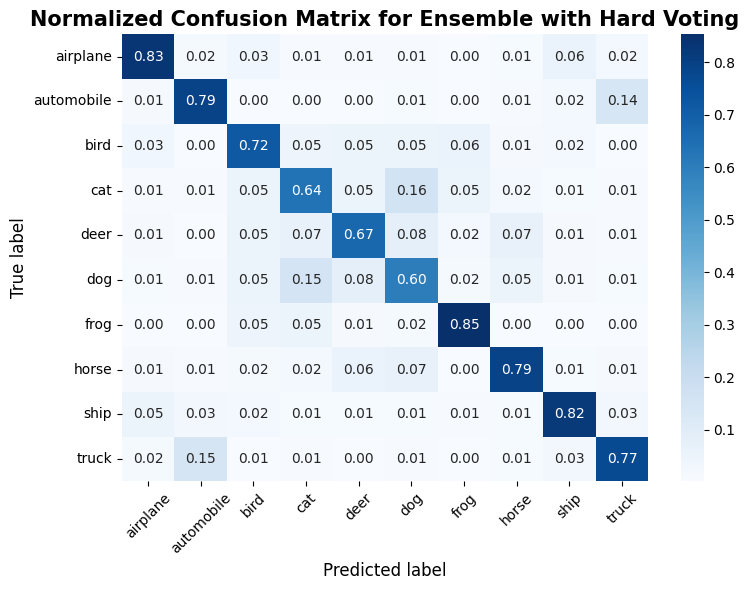

In [72]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                    'dog', 'frog', 'horse', 'ship', 'truck']

cm = confusion_matrix(y_true_hard, y_pred_hard)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)

plt.title('Normalized Confusion Matrix for Ensemble with Hard Voting', fontsize=15, fontweight='bold')
plt.xlabel('Predicted label', fontsize=12)
plt.ylabel('True label', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.grid(False) 
plt.tight_layout()
plt.show()

### Soft voting

In [19]:
ensemble_soft = EnsembleVoter(
    models={
        "alexnet": alexnet_model,
        "resnet": resnet_model,
        "baseline": baseline_model
    },
    voting="soft"
)

In [20]:
y_true_soft, y_pred_soft, y_proba_soft = get_ensemble_predictions(ensemble_soft, test_loader, device)
ensemble_metrics_soft_voting = calculate_metrics(y_true_soft, y_pred_soft, y_proba_soft)

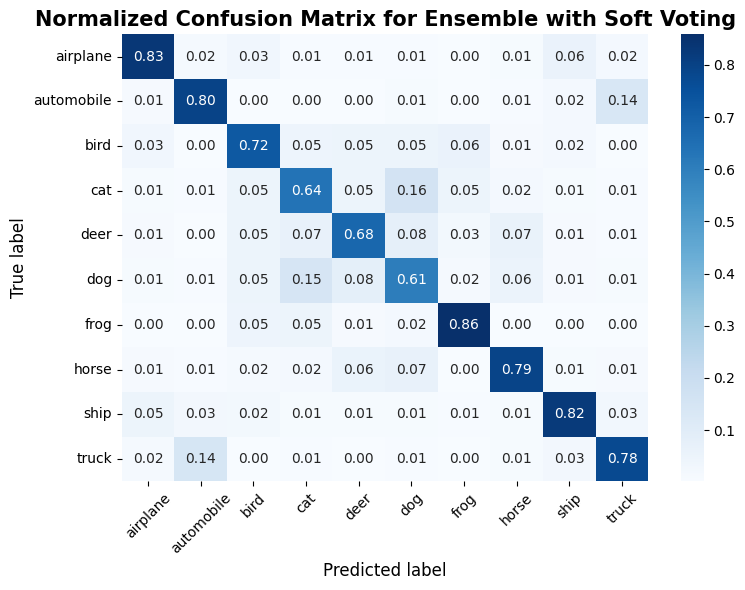

In [22]:
cm = confusion_matrix(y_true_soft, y_pred_soft)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)

plt.title('Normalized Confusion Matrix for Ensemble with Soft Voting', fontsize=15, fontweight='bold')
plt.xlabel('Predicted label', fontsize=12)
plt.ylabel('True label', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.grid(False) 
plt.tight_layout()
plt.show()

### Comparison with baseline models

In [27]:
baseline_model.to(device)
alexnet_model.to(device)
resnet_model.to(device)

y_true_baseline, y_pred_baseline, y_proba_baseline = get_predictions(baseline_model, test_loader, device)
baseline_model_metrics = calculate_metrics(y_true_baseline, y_pred_baseline, y_proba_baseline)

y_true_alexnet, y_pred_alexnet, y_proba_alexnet = get_predictions(alexnet_model, test_loader, device)
alexnet_model_metrics = calculate_metrics(y_true_alexnet, y_pred_alexnet, y_proba_alexnet)

y_true_resnet, y_pred_resnet, y_proba_resnet = get_predictions(resnet_model, test_loader, device)
resnet_model_metrics = calculate_metrics(y_true_resnet, y_pred_resnet, y_proba_resnet)

In [73]:
results = {
    "Baseline": baseline_model_metrics,
    "AlexNet": alexnet_model_metrics,
    "ResNet": resnet_model_metrics,
    "Ensemble (Soft)": ensemble_metrics_soft_voting,
    "Ensemble (Hard)": ensemble_metrics_hard_voting
}

df_results = pd.DataFrame(results).T
df_results = df_results[["accuracy", "f1_macro", "roc_auc_ovr"]]
df_results

,accuracy,f1_macro,roc_auc_ovr
Baseline,0.695922,0.694912,0.954578
AlexNet,0.743422,0.744024,0.964497
ResNet,0.635278,0.636423,0.931438
Ensemble (Soft),0.752622,0.752517,0.966506
Ensemble (Hard),0.748622,0.748593,NaN


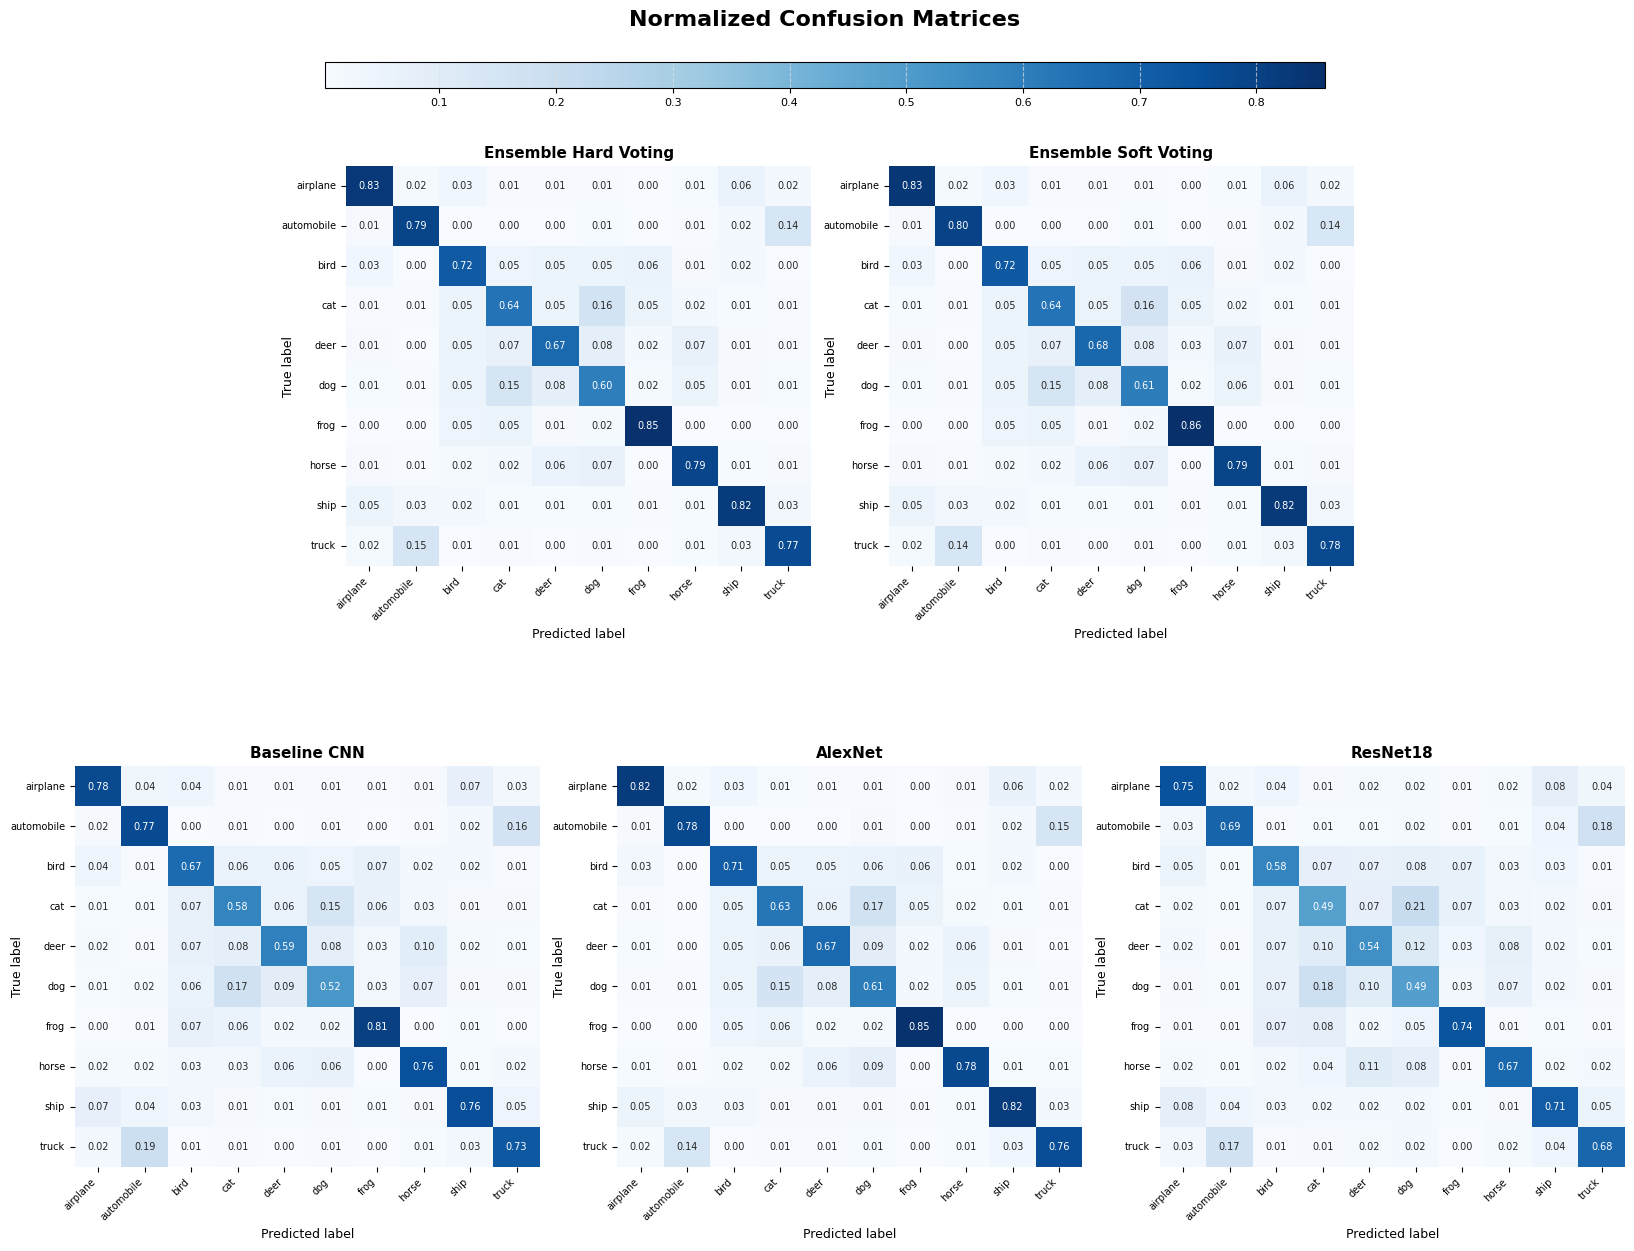

In [74]:
import matplotlib as mpl
fig = plt.figure(figsize=(20, 13))
gs = fig.add_gridspec(2, 6, hspace=0.5, wspace=0.4, top=0.88)

plots = [
    (y_true_hard, y_pred_hard, "Ensemble Hard Voting",  fig.add_subplot(gs[0, 1:3])),
    (y_true_soft, y_pred_soft, "Ensemble Soft Voting",  fig.add_subplot(gs[0, 3:5])),
    (y_true_baseline, y_pred_baseline, "Baseline CNN",  fig.add_subplot(gs[1, 0:2])),
    (y_true_alexnet,  y_pred_alexnet,  "AlexNet",       fig.add_subplot(gs[1, 2:4])),
    (y_true_resnet,   y_pred_resnet,   "ResNet18",      fig.add_subplot(gs[1, 4:6])),
]

all_cms = []
for y_true, y_pred, _, _ in plots:
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    all_cms.append(cm_norm)

vmin, vmax = min(cm.min() for cm in all_cms), max(cm.max() for cm in all_cms)

for (y_true, y_pred, title, ax), cm_norm in zip(plots, all_cms):
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, cbar=False, annot_kws={"size": 7}, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted label', fontsize=9)
    ax.set_ylabel('True label', fontsize=9, labelpad=-10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7)
    ax.grid(False)

cax = fig.add_axes([0.25, 0.94, 0.5, 0.02])
sm = mpl.cm.ScalarMappable(cmap="Blues", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
fig.colorbar(sm, cax=cax, orientation='horizontal')
cax.tick_params(labelsize=8)

fig.suptitle('Normalized Confusion Matrices', fontsize=16, fontweight='bold', y=1.0)
plt.show()